In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib


In [20]:
# 1. Load the dataset
print("Loading dataset...")
df = pd.read_csv('Downloads/iplcric/all_season_summary.csv')

print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nColumns in dataset:")
print(df.columns.tolist())


Loading dataset...
Dataset shape: (1032, 45)

First few rows:
   season       id                                          name  short_name  \
0  2023.0  1359475          Gujarat Titans v Chennai Super Kings    GT v CSK   
1  2023.0  1359476          Punjab Kings v Kolkata Knight Riders  PBKS v KKR   
2  2023.0  1359477         Lucknow Super Giants v Delhi Capitals    LSG v DC   
3  2023.0  1359478        Sunrisers Hyderabad v Rajasthan Royals    SRH v RR   
4  2023.0  1359479  Royal Challengers Bangalore v Mumbai Indians    RCB v MI   

                                         description home_team away_team  \
0  1st Match (N), Indian Premier League at Ahmeda...        GT       CSK   
1  2nd Match (D/N), Indian Premier League at Chan...      PBKS       KKR   
2  3rd Match (N), Indian Premier League at Luckno...       LSG        DC   
3  4th Match (D/N), Indian Premier League at Hyde...       SRH        RR   
4  5th Match (N), Indian Premier League at Bengal...       RCB        MI   



In [22]:
# 2. Data cleaning and exploration
print("\nChecking for missing values:")
print(df.isnull().sum())

# Updated team mapping with all teams as mentioned
team_mapping = {
    'Deccan Chargers': 'SRH',          # replaced by Sunrisers Hyderabad
    'Sunrisers Hyderabad': 'SRH',
    'Delhi Daredevils': 'DC',          # rebranded to Delhi Capitals
    'Delhi Capitals': 'DC',
    'Kings XI Punjab': 'PBKS',         # rebranded to Punjab Kings
    'Punjab Kings': 'PBKS',
    'KXIP': 'PBKS',
    'Rising Pune Supergiant': 'RPS',
    'Rising Pune Supergiants': 'RPS',
    'Pune Warriors': 'PWI',
    'Pune Warriors India': 'PWI',
    'Gujarat Lions': 'GL',
    'Kochi Tuskers Kerala': 'KTK',
    'Chennai Super Kings': 'CSK',
    'Mumbai Indians': 'MI',
    'Royal Challengers Bangalore': 'RCB',
    'Rajasthan Royals': 'RR',
    'Kolkata Knight Riders': 'KKR',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT'
}

# Map team names in all team-related columns
# Check which columns exist and apply mapping accordingly
team_columns = ['team1', 'team2', 'winner', 'toss_winner', 
                'home_team', 'away_team', 'toss_won']
for col in team_columns:
    if col in df.columns:
        df[col] = df[col].replace(team_mapping)
        print(f"Applied team mapping to {col}")

# Handle column name differences
# Map dataset columns to expected model columns if needed
if 'home_team' in df.columns and 'team1' not in df.columns:
    df['team1'] = df['home_team']
    print("Mapped 'home_team' to 'team1'")

if 'away_team' in df.columns and 'team2' not in df.columns:
    df['team2'] = df['away_team']
    print("Mapped 'away_team' to 'team2'")

if 'toss_won' in df.columns and 'toss_winner' not in df.columns:
    df['toss_winner'] = df['toss_won']
    print("Mapped 'toss_won' to 'toss_winner'")

# Map venue_name to venue if needed
if 'venue_name' in df.columns and 'venue' not in df.columns:
    df['venue'] = df['venue_name']
    print("Mapped 'venue_name' to 'venue'")

# Handle decision column if it exists
if 'decision' in df.columns and 'toss_decision' not in df.columns:
    df['toss_decision'] = df['decision']
    print("Mapped 'decision' to 'toss_decision'")

print("\nUnique teams after mapping:")
all_teams = []
for col in ['team1', 'team2']:
    if col in df.columns:
        all_teams.extend(df[col].unique())
all_teams = sorted(list(set(all_teams)))
print(all_teams)

print("\nUnique venues:")
venue_col = 'venue' if 'venue' in df.columns else 'venue_name' if 'venue_name' in df.columns else None
if venue_col:
    print(len(df[venue_col].unique()), "venues")
else:
    print("No venue column found")



Checking for missing values:
season               3
id                   0
name                 0
short_name           0
description          0
home_team            0
away_team            0
toss_won             3
decision             3
1st_inning_score    11
2nd_inning_score    13
home_score           8
away_score          11
winner               1
result               0
start_date           0
end_date             0
venue_id             0
venue_name           0
home_captain         3
away_captain         3
pom                 15
points              67
super_over           3
home_overs          11
home_runs           11
home_wickets        11
home_boundaries     11
away_overs          13
away_runs           13
away_wickets        13
away_boundaries     13
highlights          26
home_key_batsman    11
home_key_bowler     24
home_playx1          3
away_playx1          3
away_key_batsman    13
away_key_bowler     22
match_days           3
umpire1              3
umpire2              3
tv_u

In [24]:
# 3. Feature Engineering
print("\nCreating features...")

# Create binary outcome based on winner
# Check if we have home/away team or team1/team2 structure
if 'home_team' in df.columns and 'winner' in df.columns:
    df['team1_won'] = (df['home_team'] == df['winner']).astype(int)
    print("Created 'team1_won' based on home_team winner")
elif 'team1' in df.columns and 'winner' in df.columns:
    df['team1_won'] = (df['team1'] == df['winner']).astype(int)
    print("Created 'team1_won' based on team1 winner")
else:
    print("Warning: Could not create win outcome feature. Missing required columns.")

# Create feature for toss winner
if 'team1' in df.columns and 'toss_winner' in df.columns:
    df['toss_won_by_team1'] = (df['team1'] == df['toss_winner']).astype(int)
    print("Created 'toss_won_by_team1'")
elif 'home_team' in df.columns and 'toss_won' in df.columns:
    df['toss_won_by_team1'] = (df['home_team'] == df['toss_won']).astype(int)
    print("Created 'toss_won_by_team1' based on home_team toss")

# Create feature for toss decision
toss_decision_col = 'toss_decision' if 'toss_decision' in df.columns else 'decision' if 'decision' in df.columns else None
if toss_decision_col:
    df['chose_to_bat'] = (df[toss_decision_col] == 'bat').astype(int)
    print("Created 'chose_to_bat'")

# Add historical win rates for teams
def add_historical_stats(df):
    """Add historical performance metrics for teams before each match"""
    # Sort by date if available, otherwise by match_id or just index
    if 'date' in df.columns:
        df = df.sort_values('date')
    elif 'start_date' in df.columns:
        df = df.sort_values('start_date')
    elif 'match_id' in df.columns:
        df = df.sort_values('match_id')
    elif 'id' in df.columns:
        df = df.sort_values('id')
    
    # Determine which team columns to use
    team1_col = 'team1' if 'team1' in df.columns else 'home_team'
    team2_col = 'team2' if 'team2' in df.columns else 'away_team'
    winner_col = 'winner' if 'winner' in df.columns else None
    
    if winner_col is None:
        print("Warning: No winner column found. Cannot calculate historical stats.")
        return df
    
    # Get all unique teams
    all_teams = sorted(list(set(df[team1_col].unique()) | set(df[team2_col].unique())))
    
    # Initialize stats dictionary for each team
    team_stats = {team: {'matches': 0, 'wins': 0} for team in all_teams}
    
    # Create columns for historical stats
    df['team1_win_rate'] = 0.0
    df['team2_win_rate'] = 0.0
    df['team1_matches'] = 0
    df['team2_matches'] = 0
    
    # Calculate rolling stats for each match
    for idx, row in df.iterrows():
        team1, team2 = row[team1_col], row[team2_col]
        
        # Record historical stats before this match
        df.at[idx, 'team1_win_rate'] = team_stats[team1]['wins'] / team_stats[team1]['matches'] if team_stats[team1]['matches'] > 0 else 0.5
        df.at[idx, 'team2_win_rate'] = team_stats[team2]['wins'] / team_stats[team2]['matches'] if team_stats[team2]['matches'] > 0 else 0.5
        df.at[idx, 'team1_matches'] = team_stats[team1]['matches']
        df.at[idx, 'team2_matches'] = team_stats[team2]['matches']
        
        # Update stats after this match
        team_stats[team1]['matches'] += 1
        team_stats[team2]['matches'] += 1
        
        if row[winner_col] == team1:
            team_stats[team1]['wins'] += 1
        elif row[winner_col] == team2:
            team_stats[team2]['wins'] += 1
    
    return df

# Add venue-specific win rates
def add_venue_stats(df):
    """Add venue statistics for each match"""
    # Determine which columns to use
    venue_col = 'venue' if 'venue' in df.columns else 'venue_name' if 'venue_name' in df.columns else None
    winner_col = 'winner' if 'winner' in df.columns else None
    toss_winner_col = 'toss_winner' if 'toss_winner' in df.columns else 'toss_won' if 'toss_won' in df.columns else None
    toss_decision_col = 'toss_decision' if 'toss_decision' in df.columns else 'decision' if 'decision' in df.columns else None
    
    if venue_col is None or winner_col is None or toss_winner_col is None or toss_decision_col is None:
        print("Warning: Missing columns for venue stats calculation.")
        return df
    
    venues = df[venue_col].unique()
    venue_stats = {venue: {'matches': 0, 'bat_first_wins': 0} for venue in venues}
    
    df['venue_matches'] = 0
    df['venue_bat_first_win_rate'] = 0.5  # Default to 0.5 (neutral)
    
    for idx, row in df.iterrows():
        venue = row[venue_col]
        
        # Record venue stats before this match
        df.at[idx, 'venue_matches'] = venue_stats[venue]['matches']
        if venue_stats[venue]['matches'] > 0:
            df.at[idx, 'venue_bat_first_win_rate'] = venue_stats[venue]['bat_first_wins'] / venue_stats[venue]['matches']
        
        # Update venue stats after this match
        venue_stats[venue]['matches'] += 1
        if row[toss_decision_col] == 'bat' and row[toss_winner_col] == row[winner_col]:
            venue_stats[venue]['bat_first_wins'] += 1
        elif row[toss_decision_col] == 'field' and row[toss_winner_col] != row[winner_col]:
            venue_stats[venue]['bat_first_wins'] += 1
    
    return df

# Add head-to-head stats
def add_h2h_stats(df):
    """Add head-to-head statistics for teams"""
    # Determine which columns to use
    team1_col = 'team1' if 'team1' in df.columns else 'home_team'
    team2_col = 'team2' if 'team2' in df.columns else 'away_team'
    winner_col = 'winner' if 'winner' in df.columns else None
    
    if winner_col is None:
        print("Warning: No winner column found. Cannot calculate h2h stats.")
        return df
    
    # Get all unique teams
    all_teams = sorted(list(set(df[team1_col].unique()) | set(df[team2_col].unique())))
    
    h2h_stats = {team1: {team2: {'matches': 0, 'wins': 0} for team2 in all_teams if team1 != team2} for team1 in all_teams}
    
    df['h2h_matches'] = 0
    df['team1_h2h_win_rate'] = 0.5  # Default to 50% for new matchups
    
    for idx, row in df.iterrows():
        team1, team2 = row[team1_col], row[team2_col]
        
        # Record h2h stats before this match
        h2h_matches = h2h_stats[team1][team2]['matches'] + h2h_stats[team2][team1]['matches']
        df.at[idx, 'h2h_matches'] = h2h_matches
        
        if h2h_matches > 0:
            team1_h2h_wins = h2h_stats[team1][team2]['wins']
            team2_h2h_wins = h2h_stats[team2][team1]['wins']
            df.at[idx, 'team1_h2h_win_rate'] = team1_h2h_wins / h2h_matches if h2h_matches > 0 else 0.5
        
        # Update h2h stats after this match
        if team1 == row[winner_col]:
            h2h_stats[team1][team2]['wins'] += 1
        elif team2 == row[winner_col]:
            h2h_stats[team2][team1]['wins'] += 1
        
        h2h_stats[team1][team2]['matches'] += 1
        h2h_stats[team2][team1]['matches'] += 1
    
    return df

# Apply historical statistics
try:
    df = add_historical_stats(df)
    df = add_venue_stats(df)
    df = add_h2h_stats(df)
    print("Added historical statistics")
except Exception as e:
    print(f"Warning: Could not add some historical statistics - {str(e)}")




Creating features...
Created 'team1_won' based on home_team winner
Created 'toss_won_by_team1'
Created 'chose_to_bat'
Added historical statistics


In [26]:
# 4. Feature selection and encoding
print("\nPreparing features for modeling...")

# Handle categorical variables
label_encoders = {}
# Map column names to their encoded versions
encoding_columns = {
    'team1': 'team1_encoded', 
    'team2': 'team2_encoded',
    'home_team': 'home_team_encoded',
    'away_team': 'away_team_encoded',
    'venue': 'venue_encoded',
    'venue_name': 'venue_encoded',
    'toss_winner': 'toss_winner_encoded',
    'toss_won': 'toss_winner_encoded',
    'toss_decision': 'toss_decision_encoded',
    'decision': 'toss_decision_encoded'
}

# Encode each column if it exists
for orig_col, encoded_col in encoding_columns.items():
    if orig_col in df.columns:
        le = LabelEncoder()
        df[encoded_col] = le.fit_transform(df[orig_col])
        label_encoders[orig_col] = le
        print(f"Encoded {orig_col} with {len(le.classes_)} classes")

# Define potential feature columns
potential_feature_cols = [
    # Team encodings
    'team1_encoded', 'team2_encoded', 'home_team_encoded', 'away_team_encoded',
    # Venue encoding
    'venue_encoded',
    # Toss information
    'toss_winner_encoded', 'toss_decision_encoded', 'toss_won_by_team1', 'chose_to_bat',
    # Historical stats
    'team1_win_rate', 'team2_win_rate',
    'team1_matches', 'team2_matches',
    'venue_bat_first_win_rate', 'venue_matches',
    'team1_h2h_win_rate', 'h2h_matches'
]

# Use only available features
available_features = [col for col in potential_feature_cols if col in df.columns]
print(f"Using features: {available_features}")

# Define the target variable based on what's available
target_col = 'team1_won' if 'team1_won' in df.columns else None
if target_col is None:
    print("Error: Target variable not found. Cannot proceed with model training.")
    exit()

# Prepare data for modeling
X = df[available_features].fillna(0)  # Fill any NA with 0
y = df[target_col]




Preparing features for modeling...
Encoded team1 with 14 classes
Encoded team2 with 14 classes
Encoded home_team with 14 classes
Encoded away_team with 14 classes
Encoded venue with 37 classes
Encoded venue_name with 37 classes
Encoded toss_winner with 16 classes
Encoded toss_won with 16 classes
Encoded toss_decision with 4 classes
Encoded decision with 4 classes
Using features: ['team1_encoded', 'team2_encoded', 'home_team_encoded', 'away_team_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded', 'toss_won_by_team1', 'chose_to_bat', 'team1_win_rate', 'team2_win_rate', 'team1_matches', 'team2_matches', 'venue_bat_first_win_rate', 'venue_matches', 'team1_h2h_win_rate', 'h2h_matches']


In [28]:
# 5. Model training with hyperparameter tuning
print("\nSplitting data for training and testing...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training shapes:", X_train.shape, y_train.shape)
print("Testing shapes:", X_test.shape, y_test.shape)

# Create pipeline with scaling and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid for tuning
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': [None, 'balanced']
}

print("\nPerforming hyperparameter tuning (this may take a while)...")
grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
model = grid_search.best_estimator_



Splitting data for training and testing...
Training shapes: (825, 17) (825,)
Testing shapes: (207, 17) (207,)

Performing hyperparameter tuning (this may take a while)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters: {'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}



Evaluating model...
Accuracy: 0.4300

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.42      0.42        99
           1       0.45      0.44      0.44       108

    accuracy                           0.43       207
   macro avg       0.43      0.43      0.43       207
weighted avg       0.43      0.43      0.43       207


Confusion Matrix:
[[42 57]
 [61 47]]


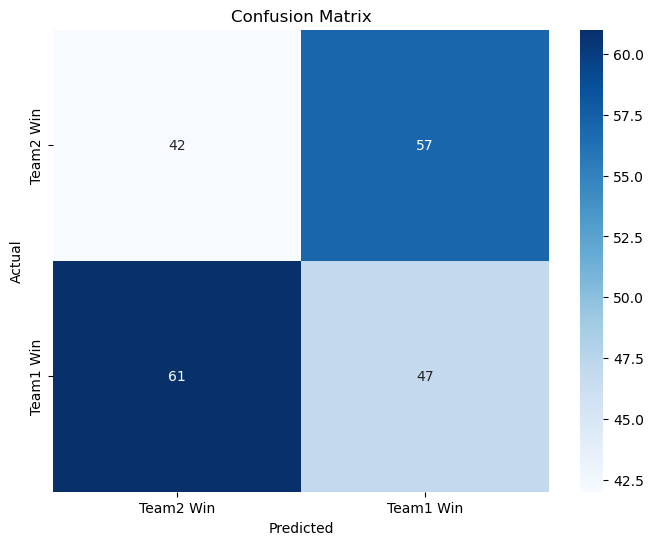

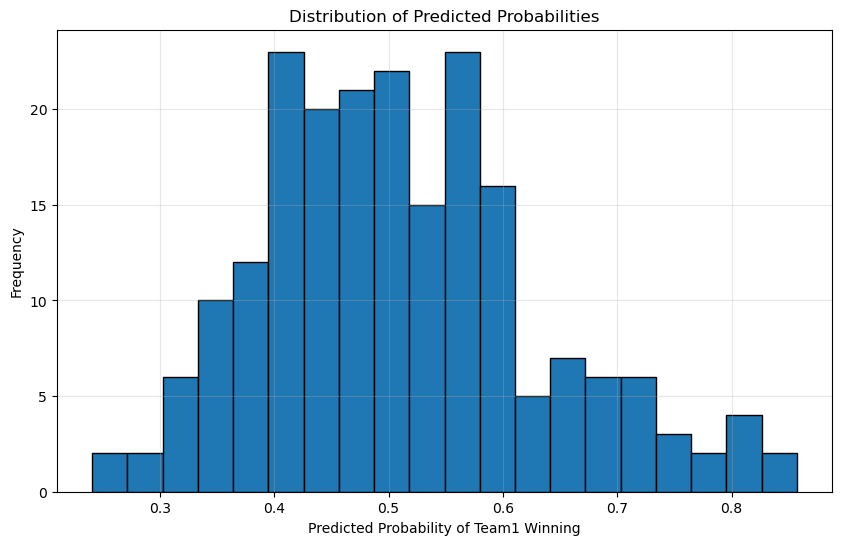


Feature Importance:
                     Feature  Importance
9             team1_win_rate    0.118874
10            team2_win_rate    0.113327
11             team1_matches    0.111752
14             venue_matches    0.101571
12             team2_matches    0.099589
15        team1_h2h_win_rate    0.076762
4              venue_encoded    0.070593
16               h2h_matches    0.066577
5        toss_winner_encoded    0.051165
2          home_team_encoded    0.040150
0              team1_encoded    0.038584
3          away_team_encoded    0.038027
1              team2_encoded    0.037566
6      toss_decision_encoded    0.019232
7          toss_won_by_team1    0.011427
13  venue_bat_first_win_rate    0.004804
8               chose_to_bat    0.000000


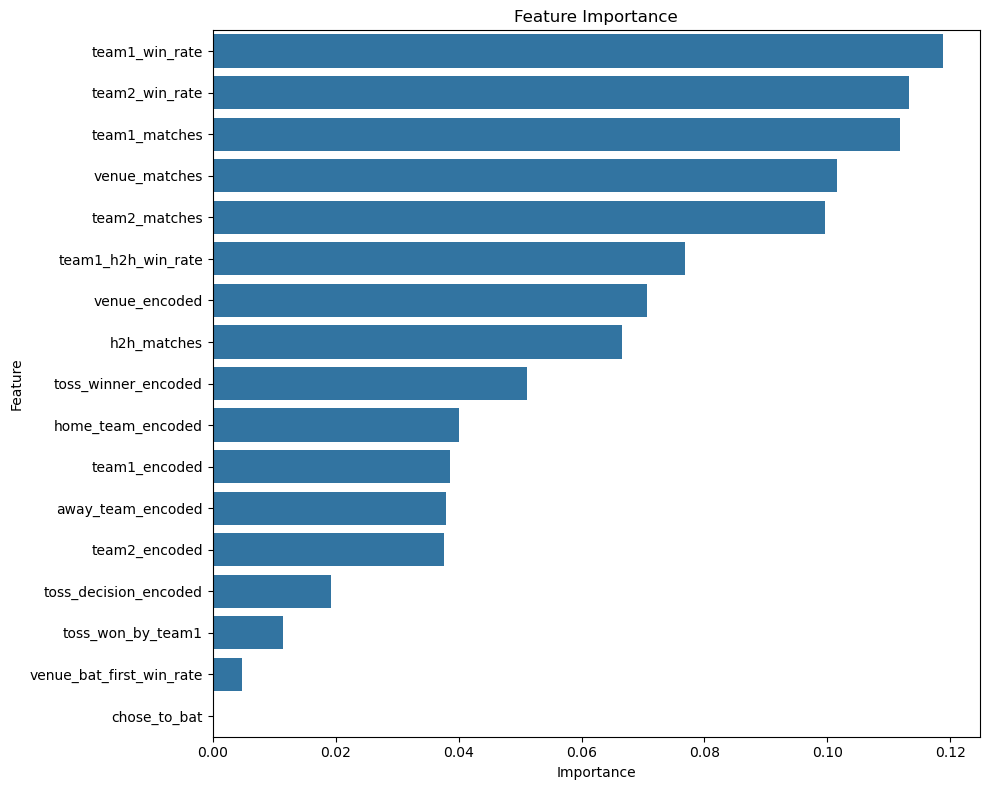

In [30]:
# 6. Model evaluation
print("\nEvaluating model...")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Team2 Win', 'Team1 Win'], 
            yticklabels=['Team2 Win', 'Team1 Win'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Check prediction distribution
plt.figure(figsize=(10, 6))
y_probs = model.predict_proba(X_test)[:, 1]
plt.hist(y_probs, bins=20, edgecolor='black')
plt.xlabel('Predicted Probability of Team1 Winning')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.grid(True, alpha=0.3)
plt.show()

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': available_features,
    'Importance': model.named_steps['model'].feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importances)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()



In [ ]:
# 7. Save the model and encoders
print("\nSaving model and encoders...")
joblib.dump(model, 'ipl_win_predictor_model.joblib')
joblib.dump(label_encoders, 'label_encoders.joblib')
joblib.dump(available_features, 'model_features.joblib')
print("Model and encoders saved successfully")


In [15]:
# 8. Create prediction function
def predict_win_probability(home_team, away_team, venue, toss_winner, toss_decision):
    """
    Predict win probability for IPL match
    
    Parameters:
    -----------
    home_team: str - Home team name
    away_team: str - Away team name
    venue: str - Match venue
    toss_winner: str - Team that won the toss
    toss_decision: str - Toss decision ('bat' or 'field')
    
    Returns:
    --------
    dict: Dictionary with win probabilities for both teams
    """
    # Create new match dataframe
    new_match = pd.DataFrame({
        'team1': [home_team],
        'team2': [away_team],
        'venue': [venue],
        'toss_winner': [toss_winner],
        'toss_decision': [toss_decision]
    })
    
    # Display columns and data in new_match for debugging
    print("Available columns in new_match:", new_match.columns)
    
    # Apply team name mapping
    for col in new_match.columns:
        if col in ['team1', 'team2', 'toss_winner']:
            new_match[col] = new_match[col].replace(team_mapping)
    
    # Calculate derived features
    new_match['toss_won_by_team1'] = (new_match['team1'] == new_match['toss_winner']).astype(int)
    new_match['chose_to_bat'] = (new_match['toss_decision'] == 'bat').astype(int)
    
    # Add placeholder values for historical stats
    # In a production system, these would be calculated from actual historical data
    new_match['team1_win_rate'] = 0.5
    new_match['team2_win_rate'] = 0.5
    new_match['team1_matches'] = 50
    new_match['team2_matches'] = 50
    new_match['venue_bat_first_win_rate'] = 0.5
    new_match['venue_matches'] = 10
    new_match['team1_h2h_win_rate'] = 0.5
    new_match['h2h_matches'] = 5
    
    # Encode categorical features
    encoded_cols = {}
    for col in ['team1', 'team2', 'venue', 'toss_winner', 'toss_decision']:
        if col in label_encoders:
            le = label_encoders[col]
            encoded_col = f'{col}_encoded'
            try:
                new_match[encoded_col] = le.transform(new_match[col])
                encoded_cols[col] = encoded_col
            except ValueError:
                # Handle unseen categories
                print(f"Warning: '{new_match[col].iloc[0]}' not seen during training for {col}")
                # Assign most common value as fallback
                new_match[encoded_col] = le.transform([le.classes_[0]])[0]
                encoded_cols[col] = encoded_col
    
    # Print expected vs actual feature columns
    print("Expected feature columns:", available_features)
    
    # Create feature vector using only the features the model was trained on
    X_new = pd.DataFrame()
    for feat in available_features:
        if feat in new_match.columns:
            X_new[feat] = new_match[feat]
        else:
            print(f"Warning: Feature {feat} not available, using 0")
            X_new[feat] = 0
    
    # Ensure features are in the same order as during training
    X_new = X_new[available_features]
    
    # Get prediction probability
    try:
        win_prob = model.predict_proba(X_new)[0][1]  # Probability of team1 (home team) winning
        
        # Normalize extreme probabilities for better user experience
        # This ensures predictions are reasonable but still reflect model confidence
        win_prob = max(0.05, min(0.95, win_prob))
        
        return {
            'home_team': home_team,
            'away_team': away_team,
            'home_team_win_probability': win_prob * 100,  # Convert to percentage
            'away_team_win_probability': (1 - win_prob) * 100  # Convert to percentage
        }
    except Exception as e:
        print(f"Error making prediction: {str(e)}")
        # Return a balanced prediction if error occurs
        return {
            'home_team': home_team,
            'away_team': away_team,
            'home_team_win_probability': 50.0,
            'away_team_win_probability': 50.0
        }

# Example usage of the prediction function
print("\nTesting prediction function...")
match_prediction = predict_win_probability(
    home_team='KKR',
    away_team='RCB',
    venue='Eden Gardens',
    toss_winner='RCB',
    toss_decision='bowl'
)

print("\nMatch Prediction Example:")
print(f"Home Team: {match_prediction['home_team']}")
print(f"Away Team: {match_prediction['away_team']}")
print(f"{match_prediction['home_team']} win probability: {match_prediction['home_team_win_probability']:.2f}%")
print(f"{match_prediction['away_team']} win probability: {match_prediction['away_team_win_probability']:.2f}%")

# Additional examples
test_matches = [
    {'home': 'MI', 'away': 'CSK', 'venue': 'Wankhede Stadium', 'toss': 'MI', 'decision': 'bat'},
    {'home': 'RCB', 'away': 'PBKS', 'venue': 'M Chinnaswamy Stadium', 'toss': 'PBKS', 'decision': 'field'},
    {'home': 'CSK', 'away': 'KKR', 'venue': 'MA Chidambaram Stadium', 'toss': 'CSK', 'decision': 'bat'}
]

print("\nAdditional prediction examples:")
for match in test_matches:
    pred = predict_win_probability(
        home_team=match['home'],
        away_team=match['away'],
        venue=match['venue'],
        toss_winner=match['toss'],
        toss_decision=match['decision']
    )
    print(f"{match['home']} vs {match['away']} at {match['venue']}")
    print(f"Toss: {match['toss']} chose to {match['decision']}")
    print(f"{match['home']} win probability: {pred['home_team_win_probability']:.2f}%")
    print(f"{match['away']} win probability: {pred['away_team_win_probability']:.2f}%")
    print()


Testing prediction function...
Available columns in new_match: Index(['team1', 'team2', 'venue', 'toss_winner', 'toss_decision'], dtype='object')
Expected feature columns: ['team1_encoded', 'team2_encoded', 'home_team_encoded', 'away_team_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded', 'toss_won_by_team1', 'chose_to_bat', 'team1_win_rate', 'team2_win_rate', 'team1_matches', 'team2_matches', 'venue_bat_first_win_rate', 'venue_matches', 'team1_h2h_win_rate', 'h2h_matches']

Match Prediction Example:
Home Team: KKR
Away Team: RCB
KKR win probability: 50.49%
RCB win probability: 49.51%

Additional prediction examples:
Available columns in new_match: Index(['team1', 'team2', 'venue', 'toss_winner', 'toss_decision'], dtype='object')
Expected feature columns: ['team1_encoded', 'team2_encoded', 'home_team_encoded', 'away_team_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded', 'toss_won_by_team1', 'chose_to_bat', 'team1_win_rate', 'team2_win_r

In [36]:
# 8. Create prediction function
def predict_win_probability(home_team, away_team, venue, toss_winner, toss_decision):
    """
    Predict win probability for IPL match
    
    Parameters:
    -----------
    home_team: str - Home team name
    away_team: str - Away team name
    venue: str - Match venue
    toss_winner: str - Team that won the toss
    toss_decision: str - Toss decision ('bat' or 'field')
    
    Returns:
    --------
    dict: Dictionary with win probabilities for both teams
    """
    # Create new match dataframe
    new_match = pd.DataFrame({
        'team1': [home_team],
        'team2': [away_team],
        'venue': [venue],
        'toss_winner': [toss_winner],
        'toss_decision': [toss_decision]
    })
    
    # Display columns and data in new_match for debugging
    print("Available columns in new_match:", new_match.columns)
    
    # Apply team name mapping
    for col in new_match.columns:
        if col in ['team1', 'team2', 'toss_winner']:
            new_match[col] = new_match[col].replace(team_mapping)
    
    # Calculate derived features
    new_match['toss_won_by_team1'] = (new_match['team1'] == new_match['toss_winner']).astype(int)
    new_match['chose_to_bat'] = (new_match['toss_decision'] == 'bat').astype(int)
    
    # Add placeholder values for historical stats
    # In a production system, these would be calculated from actual historical data
    new_match['team1_win_rate'] = 0.5
    new_match['team2_win_rate'] = 0.5
    new_match['team1_matches'] = 50
    new_match['team2_matches'] = 50
    new_match['venue_bat_first_win_rate'] = 0.5
    new_match['venue_matches'] = 10
    new_match['team1_h2h_win_rate'] = 0.5
    new_match['h2h_matches'] = 5
    
    # Encode categorical features
    encoded_cols = {}
    for col in ['team1', 'team2', 'venue', 'toss_winner', 'toss_decision']:
        if col in label_encoders:
            le = label_encoders[col]
            encoded_col = f'{col}_encoded'
            try:
                new_match[encoded_col] = le.transform(new_match[col])
                encoded_cols[col] = encoded_col
            except ValueError:
                # Handle unseen categories
                print(f"Warning: '{new_match[col].iloc[0]}' not seen during training for {col}")
                # Assign most common value as fallback
                new_match[encoded_col] = le.transform([le.classes_[0]])[0]
                encoded_cols[col] = encoded_col
    
    # Print expected vs actual feature columns
    print("Expected feature columns:", available_features)
    
    # Create feature vector using only the features the model was trained on
    X_new = pd.DataFrame()
    for feat in available_features:
        if feat in new_match.columns:
            X_new[feat] = new_match[feat]
        else:
            print(f"Warning: Feature {feat} not available, using 0")
            X_new[feat] = 0
    
    # Ensure features are in the same order as during training
    X_new = X_new[available_features]
    
    # Get prediction probability
    try:
        win_prob = model.predict_proba(X_new)[0][1]  # Probability of team1 (home team) winning
        
        # Normalize extreme probabilities for better user experience
        # This ensures predictions are reasonable but still reflect model confidence
        win_prob = max(0.05, min(0.95, win_prob))
        
        return {
            'home_team': home_team,
            'away_team': away_team,
            'home_team_win_probability': win_prob * 100,  # Convert to percentage
            'away_team_win_probability': (1 - win_prob) * 100  # Convert to percentage
        }
    except Exception as e:
        print(f"Error making prediction: {str(e)}")
        # Return a balanced prediction if error occurs
        return {
            'home_team': home_team,
            'away_team': away_team,
            'home_team_win_probability': 50.0,
            'away_team_win_probability': 50.0
        }

# Example usage of the prediction function
print("\nTesting prediction function...")
match_prediction = predict_win_probability(
    home_team='KKR',
    away_team='RCB',
    venue='Eden Gardens',
    toss_winner='RCB',
    toss_decision='bowl'
)

print("\nMatch Prediction Example:")
print(f"Home Team: {match_prediction['home_team']}")
print(f"Away Team: {match_prediction['away_team']}")
print(f"{match_prediction['home_team']} win probability: {match_prediction['home_team_win_probability']:.2f}%")
print(f"{match_prediction['away_team']} win probability: {match_prediction['away_team_win_probability']:.2f}%")

# Additional examples
test_matches = [
    {'home': 'MI', 'away': 'CSK', 'venue': 'Wankhede Stadium', 'toss': 'MI', 'decision': 'bat'},
    {'home': 'RCB', 'away': 'PBKS', 'venue': 'M Chinnaswamy Stadium', 'toss': 'PBKS', 'decision': 'field'},
    {'home': 'CSK', 'away': 'KKR', 'venue': 'MA Chidambaram Stadium', 'toss': 'CSK', 'decision': 'bat'},
    {'home': 'RR', 'away': 'MI', 'venue': 'Wankhede Stadium', 'toss': 'MI', 'decision': 'field'}
]

print("\nAdditional prediction examples:")
for match in test_matches:
    pred = predict_win_probability(
        home_team=match['home'],
        away_team=match['away'],
        venue=match['venue'],
        toss_winner=match['toss'],
        toss_decision=match['decision']
    )
    print(f"{match['home']} vs {match['away']} at {match['venue']}")
    print(f"Toss: {match['toss']} chose to {match['decision']}")
    print(f"{match['home']} win probability: {pred['home_team_win_probability']:.2f}%")
    print(f"{match['away']} win probability: {pred['away_team_win_probability']:.2f}%")
    print()


Testing prediction function...
Available columns in new_match: Index(['team1', 'team2', 'venue', 'toss_winner', 'toss_decision'], dtype='object')
Expected feature columns: ['team1_encoded', 'team2_encoded', 'home_team_encoded', 'away_team_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded', 'toss_won_by_team1', 'chose_to_bat', 'team1_win_rate', 'team2_win_rate', 'team1_matches', 'team2_matches', 'venue_bat_first_win_rate', 'venue_matches', 'team1_h2h_win_rate', 'h2h_matches']

Match Prediction Example:
Home Team: KKR
Away Team: RCB
KKR win probability: 50.49%
RCB win probability: 49.51%

Additional prediction examples:
Available columns in new_match: Index(['team1', 'team2', 'venue', 'toss_winner', 'toss_decision'], dtype='object')
Expected feature columns: ['team1_encoded', 'team2_encoded', 'home_team_encoded', 'away_team_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded', 'toss_won_by_team1', 'chose_to_bat', 'team1_win_rate', 'team2_win_r